In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load Processed Data
import pickle

x_train = pickle.load(open("../models/x_train_cls.pkl", "rb"))
x_test = pickle.load(open("../models/x_test_cls.pkl", "rb"))
y_train = pickle.load(open("../models/y_train_cls.pkl", "rb"))
y_test = pickle.load(open("../models/y_test_cls.pkl", "rb"))

print(x_train.shape)
print(x_test.shape)

(80000, 28)
(20000, 28)


In [3]:
pip install catboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [5]:
# Create Models

models = {
    "Logistic Regression":LogisticRegression(),
    "Decision Tree":DecisionTreeClassifier(random_state=42),
    "Random Forest":RandomForestClassifier(random_state=42),
    "Gradient Boosing":GradientBoostingClassifier(random_state=42),
    "AdaBoost":AdaBoostClassifier(random_state=42),
    "Extra Trees":ExtraTreesClassifier(random_state=42),
    "XGBoost":XGBClassifier(eval_metrics="logloss", random_state=42),
    "CatBoost":CatBoostClassifier(verbose=0, random_state=42)
}

In [6]:
# Train Models
results = []
best_model = None
best_accuracy = 0

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

In [8]:
# Model Training Loop

for name, model in models.items():
    print(f"Training {name}....")
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred)
    results.append([
        name, accuracy, precision, recall, f1, roc
    ])

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model

Training Logistic Regression....
Training Decision Tree....
Training Random Forest....
Training Gradient Boosing....
Training AdaBoost....
Training Extra Trees....
Training XGBoost....
Training CatBoost....


In [9]:
# model Comparison

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

results_df.sort_values(
    by="Accuracy",
    ascending=False,
    inplace=True
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.56995,0.578788,0.772585,0.661791,0.550105
3,Gradient Boosing,0.56650,0.572958,0.801047,0.668070,0.543529
4,AdaBoost,0.56250,0.574128,0.761568,0.654696,0.543004
7,CatBoost,0.56060,0.574525,0.744583,0.648592,0.542581
5,Extra Trees,0.55320,0.570563,0.726037,0.638979,0.536273
2,Random Forest,0.55050,0.570153,0.709603,0.632281,0.534918
6,XGBoost,0.54910,0.570632,0.695006,0.626708,0.534811
1,Decision Tree,0.50690,0.547987,0.539938,0.543933,0.503664


In [10]:
# Best Model
print("Best Model :", best_model)
print("Best Accuracy :", best_accuracy)

Best Model : LogisticRegression()
Best Accuracy : 0.56995


In [11]:
# Classification Report
y_pred = best_model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.55      0.33      0.41      9108
           1       0.58      0.77      0.66     10892

    accuracy                           0.57     20000
   macro avg       0.56      0.55      0.54     20000
weighted avg       0.56      0.57      0.55     20000



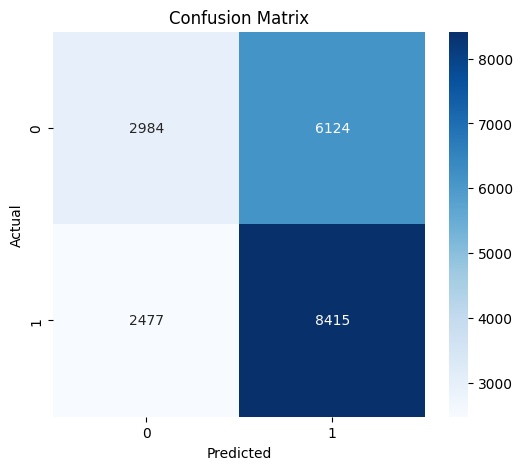

In [12]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [14]:
# Save Best Model
pickle.dump(best_model, open("../models/placement_model.pkl", "wb"))
print("Placement model saved successfully.")

Placement model saved successfully.


In [15]:
# Verify Saved Model
model = pickle.load(open("../models/placement_model.pkl", "rb"))
print(type(model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [16]:
# Save the entire comparison table as a CSV.
results_df.to_csv("../models/classification_results.csv", index=False)
print("Classification results saved successfully.")

Classification results saved successfully.
